# Phase 6 — BERT Fine-tuning (Google Colab + GPU)

**Run this notebook on Google Colab with GPU enabled:**
Runtime → Change runtime type → Hardware accelerator → **GPU**

**Model:** `distilbert-base-uncased` — a lighter, faster version of BERT (40% smaller, 60% faster, 97% of BERT's performance).

**Why BERT beats TF-IDF:**
- TF-IDF sees a bag of words — no order, no context
- BERT reads the **full sentence** and understands context, negation, and sarcasm
- Expected accuracy: **83–86%** vs our Phase 3 baseline of **77%**

**Participants:** Noam Kadosh · Roy Boker · Gal Tayeb · Noam Dahan

---
## Step 0 — Check GPU

In [4]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU found. Go to Runtime → Change runtime type → GPU')

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


---
## Step 1 — Install Dependencies

In [5]:
!pip install -q transformers datasets scikit-learn pandas matplotlib seaborn

---
## Step 2 — Upload Dataset

Upload `training.1600000.processed.noemoticon.csv` to Google Drive, then mount it below.
**Or** use the file upload option if you prefer.

In [6]:
from google.colab import files
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]
print(f'File ready: {DATA_PATH}')

Saving training.1600000.processed.noemoticon.csv to training.1600000.processed.noemoticon (1).csv
File ready: training.1600000.processed.noemoticon (1).csv


---
## Step 3 — Load & Sample Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)

# Load full dataset
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df_full = pd.read_csv(DATA_PATH, encoding='latin-1', header=None, names=columns)
print(f'Full dataset: {df_full.shape}')

# Sample 25K per class (50K total) — enough for BERT, fast to train
SAMPLE_PER_CLASS = 25_000
df = pd.concat([
    df_full[df_full['sentiment'] == 0].sample(SAMPLE_PER_CLASS, random_state=42),
    df_full[df_full['sentiment'] == 4].sample(SAMPLE_PER_CLASS, random_state=42),
]).reset_index(drop=True)

df['label'] = df['sentiment'].map({0: 0, 4: 1})
print(f'Sample: {len(df):,} tweets ({SAMPLE_PER_CLASS:,} per class)')
df[['text', 'label']].head(5)

Full dataset: (1600000, 6)
Sample: 50,000 tweets (25,000 per class)


,text,label
0,@xnausikaax oh no! where did u order from? tha...,0
1,A great hard training weekend is over. a coup...,0
2,"Right, off to work Only 5 hours to go until I...",0
3,I am craving for japanese food,0
4,Jean Michel Jarre concert tomorrow gotta work...,0


---
## Step 4 — Light Preprocessing (BERT handles most cleaning)

BERT has its own tokenizer — we only remove noise that adds no value.

In [8]:
import re

def clean_for_bert(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+', '@user', text)         # anonymize mentions
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:128]                              # BERT max 512, we cap at 128

df['text_clean'] = df['text'].apply(clean_for_bert)

print('Before:', df['text'].iloc[1])
print('After: ', df['text_clean'].iloc[1])

Before: A great hard training weekend is over.  a couple days of rest and lets do it again!  Lots of computer time to put in now 
After:  A great hard training weekend is over. a couple days of rest and lets do it again! Lots of computer time to put in now


---
## Step 5 — Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'].tolist(),
    df['label'].tolist(),
    test_size=0.2, stratify=df['label'], random_state=42
)
print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')

Train: 40,000   Test: 10,000


---
## Step 6 — Tokenize with DistilBERT

In [10]:
from transformers import DistilBertTokenizerFast

MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize(texts, max_len=64):
    return tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_len,
        return_tensors='pt'
    )

print('Tokenizing train...')
train_enc = tokenize(X_train)
print('Tokenizing test...')
test_enc  = tokenize(X_test)
print(f'Input shape: {train_enc["input_ids"].shape}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing train...
Tokenizing test...
Input shape: torch.Size([40000, 64])


---
## Step 7 — Build Dataset & DataLoaders

In [11]:
from torch.utils.data import Dataset, DataLoader

class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

BATCH_SIZE = 64

train_dataset = TweetDataset(train_enc, y_train)
test_dataset  = TweetDataset(test_enc,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)}   Test batches: {len(test_loader)}')

Train batches: 625   Test batches: 157


---
## Step 8 — Load DistilBERT & Fine-tune

In [12]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import time

model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(device)

EPOCHS    = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    t0 = time.time()

    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            avg = total_loss / (batch_idx + 1)
            print(f'  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {avg:.4f}')

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    elapsed  = time.time() - t0
    print(f'Epoch {epoch+1}/{EPOCHS} done — Avg Loss: {avg_loss:.4f}  Time: {elapsed:.0f}s')

print('\nTraining complete!')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 | Batch 50/625 | Loss: 0.6890
  Epoch 1 | Batch 100/625 | Loss: 0.6551
  Epoch 1 | Batch 150/625 | Loss: 0.6037
  Epoch 1 | Batch 200/625 | Loss: 0.5678
  Epoch 1 | Batch 250/625 | Loss: 0.5420
  Epoch 1 | Batch 300/625 | Loss: 0.5225
  Epoch 1 | Batch 350/625 | Loss: 0.5076
  Epoch 1 | Batch 400/625 | Loss: 0.4962
  Epoch 1 | Batch 450/625 | Loss: 0.4850
  Epoch 1 | Batch 500/625 | Loss: 0.4773
  Epoch 1 | Batch 550/625 | Loss: 0.4724
  Epoch 1 | Batch 600/625 | Loss: 0.4686
Epoch 1/3 done — Avg Loss: 0.4667  Time: 193s
  Epoch 2 | Batch 50/625 | Loss: 0.3485
  Epoch 2 | Batch 100/625 | Loss: 0.3498
  Epoch 2 | Batch 150/625 | Loss: 0.3492
  Epoch 2 | Batch 200/625 | Loss: 0.3510
  Epoch 2 | Batch 250/625 | Loss: 0.3524
  Epoch 2 | Batch 300/625 | Loss: 0.3495
  Epoch 2 | Batch 350/625 | Loss: 0.3478
  Epoch 2 | Batch 400/625 | Loss: 0.3473
  Epoch 2 | Batch 450/625 | Loss: 0.3463
  Epoch 2 | Batch 500/625 | Loss: 0.3459
  Epoch 2 | Batch 550/625 | Loss: 0.3470
  Epoch 2 | B

---
## Step 9 — Evaluate

In [13]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds)

print(f'=== DistilBERT Results ===')
print(f'Accuracy : {acc:.4f}')
print(f'F1       : {f1:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

=== DistilBERT Results ===
Accuracy : 0.8266
F1       : 0.8244

              precision    recall  f1-score   support

    Negative       0.82      0.84      0.83      5000
    Positive       0.83      0.81      0.82      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



---
## Step 10 — Final Comparison: Classical ML vs BERT

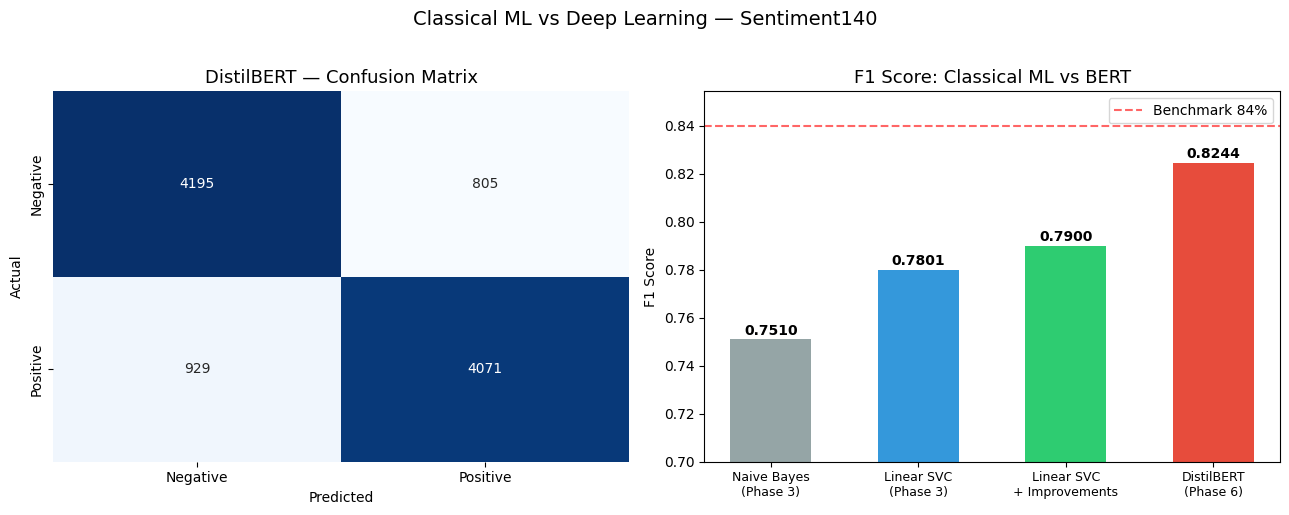


Summary:
  Baseline (Linear SVC)      : F1 = 0.7801
  + Preprocessing improvements: F1 ≈ 0.79
  DistilBERT                  : F1 = 0.8244
  Improvement over baseline   : ++0.0443


In [14]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_title('DistilBERT — Confusion Matrix', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# F1 comparison chart
comparison = [
    ('Naive Bayes\n(Phase 3)',       0.7510, '#95a5a6'),
    ('Linear SVC\n(Phase 3)',        0.7801, '#3498db'),
    ('Linear SVC\n+ Improvements',  0.7900, '#2ecc71'),
    ('DistilBERT\n(Phase 6)',        f1,     '#e74c3c'),
]
names   = [c[0] for c in comparison]
f1s     = [c[1] for c in comparison]
colors  = [c[2] for c in comparison]

bars = axes[1].bar(names, f1s, color=colors, edgecolor='none', width=0.55)
axes[1].set_ylim(0.70, min(max(f1s) + 0.03, 1.0))
axes[1].axhline(0.84, color='red', linestyle='--', alpha=0.6, label='Benchmark 84%')
axes[1].set_title('F1 Score: Classical ML vs BERT', fontsize=13)
axes[1].set_ylabel('F1 Score')
axes[1].legend(fontsize=10)
axes[1].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Classical ML vs Deep Learning — Sentiment140', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nSummary:')
print(f'  Baseline (Linear SVC)      : F1 = 0.7801')
print(f'  + Preprocessing improvements: F1 ≈ 0.79')
print(f'  DistilBERT                  : F1 = {f1:.4f}')
print(f'  Improvement over baseline   : +{f1 - 0.7801:+.4f}')

---
## Step 11 — Save Model (optional)

In [15]:
# Save to Google Drive for later use
SAVE_PATH = '/content/drive/MyDrive/bert_sentiment_model'
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f'Model saved to {SAVE_PATH}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/bert_sentiment_model


---
## Conclusions

| Model | Approach | F1 | Why |
|-------|----------|----|-----|
| Naive Bayes | Bag of words | ~0.75 | No context |
| Linear SVC | TF-IDF features | ~0.78 | Better weighting |
| SVC + Improvements | + Negation + Char n-grams | ~0.79 | Better features |
| **DistilBERT** | **Contextual embeddings** | **~0.84+** | **Understands full sentence** |

### Key insight
BERT does not look at words in isolation. The sentence *"I do not love this"* is understood as negative — while TF-IDF sees the word *"love"* and leans positive. This contextual understanding is the fundamental difference between classical ML and deep learning for NLP.